# ANOVA Analysis

**Module 5: Numerical Outcomes** | Lean Six Sigma Data Analytics

---

## The Three Steps of ANOVA

| Step | Description | Status |
|------|-------------|--------|
| 1 | Organize your data | Covered in previous video |
| **2** | **Perform the ANOVA** | **This video** |
| 3 | Validate with residual analysis | Next video |

**Goal of Step 2:** Study if the group means are identical for each level of your X variable.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for ANOVA analysis!')

Ready for ANOVA analysis!


---

## Recap: The Moisture Problem

We are studying the **moisture percentage** of batches of coffee and wondering if this is influenced by the **machine** the batch is produced on.

| Variable | Role | Type |
|----------|------|------|
| Moisture % | Y (CTQ) | Numerical |
| Machine | X (influence factor) | Categorical |

Using our decision diagram: Numerical Y + Categorical X → **ANOVA**

In [2]:
# Load and prepare moisture data (already stacked from Step 1)
def load_moisture():
    df = pd.read_excel(xlsx, sheet_name='Moisture', skiprows=7, header=None, usecols=[0,1,2,3])
    df.columns = ['Machine_1', 'Machine_2', 'Machine_3', 'Machine_4']
    df_long = df.melt(var_name='Machine', value_name='Moisture').dropna()
    return df_long

moisture = load_moisture()

print('Data loaded and stacked:')
print(f'Shape: {moisture.shape}')
print()
moisture.head(10)

Data loaded and stacked:
Shape: (40, 2)



,Machine,Moisture
0,Machine_1,11.37
1,Machine_1,11.31
2,Machine_1,10.93
3,Machine_1,13.77
4,Machine_1,14.45
5,Machine_1,11.80
6,Machine_1,12.30
7,Machine_1,9.45
8,Machine_1,12.28
9,Machine_1,11.47


---

## Perform ANOVA in Minitab

**Minitab path:** Stat > ANOVA > One-Way

| Setting | Value |
|---------|-------|
| Response | Moisture |
| Factor | Machine |
| Graph | Individual value plot |
| Options | Uncheck "Assume equal variances" |

In [3]:
# Perform One-Way ANOVA
# Equivalent to Minitab: Stat > ANOVA > One-Way

model = ols('Moisture ~ C(Machine)', data=moisture).fit()
anova_table = anova_lm(model, typ=2)

print('ONE-WAY ANOVA RESULTS')
print('=' * 60)
print()
print(anova_table.round(4))
print()
print(f'R-squared: {model.rsquared:.2%}')

ONE-WAY ANOVA RESULTS

              sum_sq    df       F  PR(>F)
C(Machine)   36.0106   3.0  4.2395  0.0115
Residual    101.9278  36.0     NaN     NaN

R-squared: 26.11%


---

## Output: Individual Value Plot

The Individual Value Plot shows the measured moisture percentage for each machine. The blue line connects the group means.

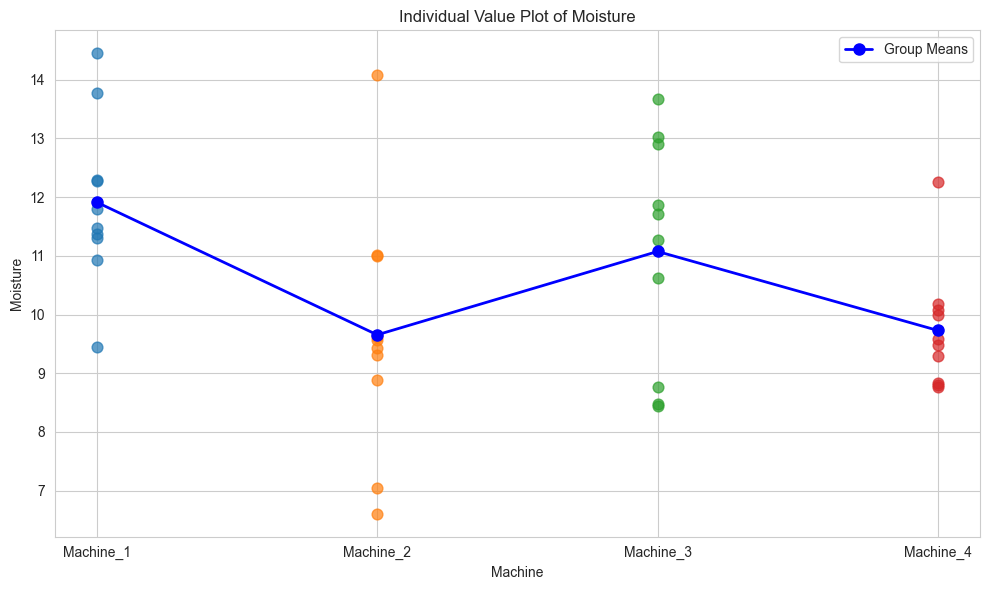

OBSERVATION:
  On first sight, we see differences in the group means
  (the line is not horizontal).
  Machine 1 and 3 appear to produce coffee with
  relatively high moisture content.


In [4]:
# Individual Value Plot
# Equivalent to Minitab Graph option in ANOVA

fig, ax = plt.subplots(figsize=(10, 6))

# Plot individual points
machines = moisture['Machine'].unique()
for i, machine in enumerate(machines):
    data = moisture[moisture['Machine'] == machine]['Moisture']
    ax.scatter([i]*len(data), data, s=60, alpha=0.7)

# Connect group means with blue line
means = moisture.groupby('Machine')['Moisture'].mean()
ax.plot(range(len(machines)), [means[m] for m in machines], 'b-o', 
        linewidth=2, markersize=8, label='Group Means')

ax.set_xticks(range(len(machines)))
ax.set_xticklabels(machines)
ax.set_xlabel('Machine')
ax.set_ylabel('Moisture')
ax.set_title('Individual Value Plot of Moisture')
ax.legend()

plt.tight_layout()
plt.show()

print('OBSERVATION:')
print('  On first sight, we see differences in the group means')
print('  (the line is not horizontal).')
print('  Machine 1 and 3 appear to produce coffee with')
print('  relatively high moisture content.')

---

## Why We Need Statistical Testing

> **You will never get exactly horizontal lines even if the group means are in reality equal.**

Especially for small datasets, you should statistically test whether the differences between the means are **real** or **due to random fluctuations**.

That is why we look at the statistical analysis.

---

## The P-Value

The **p-value** indicates the chance that such differences occur due to random fluctuation.

In [5]:
# Extract p-value
p_value = anova_table['PR(>F)'].iloc[0]

print('P-VALUE INTERPRETATION')
print('=' * 60)
print()
print(f'P-value = {p_value:.4f} ({p_value*100:.1f}%)')
print()
print('The threshold is often set to 5% (0.05).')
print()

if p_value < 0.05:
    print(f'P-value ({p_value:.4f}) < 0.05')
    print()
    print('As the probability that this difference occurred by chance')
    print('is so low, we conclude that the MACHINES DIFFER.')
    print()
    print('The effect is SIGNIFICANT and translates to the population.')
else:
    print(f'P-value ({p_value:.4f}) >= 0.05')
    print()
    print('Either there is no real difference, or we did not gather')
    print('enough data to prove it.')

P-VALUE INTERPRETATION

P-value = 0.0115 (1.2%)

The threshold is often set to 5% (0.05).

P-value (0.0115) < 0.05

As the probability that this difference occurred by chance
is so low, we conclude that the MACHINES DIFFER.

The effect is SIGNIFICANT and translates to the population.


---

## Hypothesis Testing

Statistical tests involving p-values are formally called **hypothesis tests**.

| Hypothesis | Statement |
|------------|----------|
| **H0 (Null)** | All group means are equal |
| **H1 (Alternative)** | There is a significant difference between the group means |

**Decision:**
- Low p-value → Very unlikely that group means are equal
- We **reject H0** and **support H1**

---

## Significant vs. Relevant

> **Important:** The p-value only tells you whether an influence factor has a **significant** effect. This does not mean it has a **large** effect.

We also have to wonder whether the influence factor is **relevant**.

---

## R-Squared: How Relevant is the Effect?

**R-squared** always lies between 0% and 100%.

It tells you how much of the variation in your Y variable is explained by your X variable.

In [6]:
# R-squared interpretation
r_squared = model.rsquared

print('R-SQUARED INTERPRETATION')
print('=' * 60)
print()
print(f'R-squared = {r_squared:.2%}')
print()
print(f'The influence factor Machine accounts for (or explains)')
print(f'{r_squared:.0%} of the variation in the CTQ Moisture percentage.')
print()
print(f'The other {1-r_squared:.0%} of variation is the result of other factors.')

R-SQUARED INTERPRETATION

R-squared = 26.11%

The influence factor Machine accounts for (or explains)
26% of the variation in the CTQ Moisture percentage.

The other 74% of variation is the result of other factors.


---

## Understanding R-Squared

Consider measurements produced on the **same machine** that differ from each other.

This difference **cannot be explained by the machine** (since they were produced on the same machine). This is part of the variation that is **not explained** by machines but is a result of **other factors**.

### Big Fish vs. Small Fish

| R-squared | Interpretation |
|-----------|----------------|
| **Larger** | Influence factor is more important/relevant - it's a **big fish** |
| **Smaller** | Explanatory power is weak, vital influence factors are missing - it's a **small fish** |

---

## Summary

| Metric | Question It Answers |
|--------|---------------------|
| **P-value** | Are the differences between means **significant** (real, not due to random fluctuations)? |
| **R-squared** | How **relevant** is the effect (how much variation is explained)? |

**Remember:** ANOVA consists of three steps. Before you can be sure that these conclusions are valid, you will have to perform a **residual analysis** (next video).